<a href="https://colab.research.google.com/github/Tamasha-Ab/CNN-Model1/blob/main/6_4_QCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1: Install Dependencies
!pip install tensorflow tensorflow-hub tensorflowjs kaggle opencv-python scikit-learn pandas matplotlib seaborn requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.4.3 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.34.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [2]:
# CELL 2: Import Libraries
import tensorflow as tf
import numpy as np
import os
import json
import cv2
from zipfile import ZipFile
import requests
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import tensorflowjs as tfjs

In [3]:
# CELL 3: Download and Extract Dataset
# Setup Kaggle credentials
try:
    kaggle_dictionary = json.load(open("kaggle.json"))
    os.environ["KAGGLE_USERNAME"] = kaggle_dictionary["username"]
    os.environ["KAGGLE_KEY"] = kaggle_dictionary["key"]
    print("Kaggle credentials loaded successfully")
except FileNotFoundError:
    print("kaggle.json not found. Please ensure Kaggle API credentials are set up.")

# Download and extract dataset
def setup_dataset():
    print("Downloading dataset...")
    try:
        !kaggle datasets download -d ravirajsinh45/real-life-industrial-dataset-of-casting-product
        dataset_zip = "real-life-industrial-dataset-of-casting-product.zip"
    except Exception as e:
        print("Kaggle API download failed. Using direct download...")
        url = "https://www.dropbox.com/s/ye45pv59nk4jbst/casting_data.zip?dl=1"
        response = requests.get(url)
        dataset_zip = "casting_data.zip"
        with open(dataset_zip, 'wb') as f:
            f.write(response.content)

    print("Extracting dataset...")
    with ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall()
    print("Dataset extracted successfully!")

setup_dataset()

Kaggle credentials loaded successfully
Dataset URL: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 89% 89.0M/100M [00:00<00:00, 932MB/s]
100% 100M/100M [00:00<00:00, 721MB/s] 
Extracting dataset...
Dataset extracted successfully!


In [4]:
# CELL 4: Organize Dataset (Binary Classification)
def organize_dataset():
    print("Starting dataset organization...")

    # Define paths
    source_dir = 'casting_512x512/casting_512x512'
    base_path = 'casting_data'

    # Clean up existing organized data
    if os.path.exists(base_path):
        shutil.rmtree(base_path)
        print("Cleaned up existing organized data")

    # Create directories for binary classification
    for split in ['train', 'test']:
        for category in ['defective', 'non_defective']:
            os.makedirs(os.path.join(base_path, split, category), exist_ok=True)

    # Get all images
    defect_dir = os.path.join(source_dir, 'def_front')
    ok_dir = os.path.join(source_dir, 'ok_front')

    defect_files = sorted([f for f in os.listdir(defect_dir) if f.endswith('.jpeg')])
    ok_files = sorted([f for f in os.listdir(ok_dir) if f.endswith('.jpeg')])

    print(f"Found {len(defect_files)} defective images and {len(ok_files)} non-defective images")

    # Split into train/test (80/20 split)
    from sklearn.model_selection import train_test_split

    def split_and_organize(files, src_dir, is_defect=True):
        train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

        processed_count = 0
        total_files = len(train_files) + len(test_files)

        # Process each split
        for split, split_files in [('train', train_files), ('test', test_files)]:
            category = 'defective' if is_defect else 'non_defective'
            dst_dir = os.path.join(base_path, split, category)

            print(f"\nProcessing {split} split for {category} images...")

            for img_file in split_files:
                src_path = os.path.join(src_dir, img_file)
                shutil.copy2(src_path, dst_dir)

                processed_count += 1
                if processed_count % 50 == 0:
                    print(f"Processed {processed_count}/{total_files} images...")

    # Process both defect and ok images
    print("\nOrganizing defective images...")
    split_and_organize(defect_files, defect_dir, True)

    print("\nOrganizing non-defective images...")
    split_and_organize(ok_files, ok_dir, False)

    # Print final dataset statistics
    print("\nFinal Dataset Statistics:")
    total_images = 0
    for split in ['train', 'test']:
        print(f"\n{split.upper()} Directory:")
        split_total = 0
        for category in ['defective', 'non_defective']:
            path = os.path.join(base_path, split, category)
            files = os.listdir(path) if os.path.exists(path) else []
            file_count = len(files)
            split_total += file_count
            print(f"{category}: {file_count} images")
        total_images += split_total
        print(f"Total {split} images: {split_total}")
    print(f"\nTotal dataset images: {total_images}")

# Run the organization
organize_dataset()

Starting dataset organization...
Cleaned up existing organized data
Found 781 defective images and 519 non-defective images

Organizing defective images...

Processing train split for defective images...
Processed 50/781 images...
Processed 100/781 images...
Processed 150/781 images...
Processed 200/781 images...
Processed 250/781 images...
Processed 300/781 images...
Processed 350/781 images...
Processed 400/781 images...
Processed 450/781 images...
Processed 500/781 images...
Processed 550/781 images...
Processed 600/781 images...

Processing test split for defective images...
Processed 650/781 images...
Processed 700/781 images...
Processed 750/781 images...

Organizing non-defective images...

Processing train split for non_defective images...
Processed 50/519 images...
Processed 100/519 images...
Processed 150/519 images...
Processed 200/519 images...
Processed 250/519 images...
Processed 300/519 images...
Processed 350/519 images...
Processed 400/519 images...

Processing test sp

In [5]:
# CELL 4.5: Verify Dataset Structure
import os

def verify_dataset():
    base_dir = 'casting_data'
    for split in ['train', 'test']:
        print(f"\n{split.upper()} Directory:")
        split_path = os.path.join(base_dir, split)
        if os.path.exists(split_path):
            for category in ['defective', 'non_defective']:
                category_path = os.path.join(split_path, category)
                if os.path.exists(category_path):
                    files = os.listdir(category_path)
                    print(f"{category}: {len(files)} images")
                else:
                    print(f"{category}: directory not found")
        else:
            print(f"{split} directory not found")

verify_dataset()


TRAIN Directory:
defective: 624 images
non_defective: 415 images

TEST Directory:
defective: 157 images
non_defective: 104 images


In [6]:
# CELL 5: Setup Data Generators and Build Model
def setup_data_generators(base_dir='casting_data'):
    print("Setting up data generators...")

    # Data augmentation for training
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2
    )

    # Only rescaling for testing
    test_datagen = ImageDataGenerator(rescale=1./255)

    print("Creating generators...")
    train_generator = train_datagen.flow_from_directory(
        os.path.join(base_dir, 'train'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        subset='training'
    )

    validation_generator = train_datagen.flow_from_directory(
        os.path.join(base_dir, 'train'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        subset='validation'
    )

    test_generator = test_datagen.flow_from_directory(
        os.path.join(base_dir, 'test'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    return train_generator, validation_generator, test_generator

def build_model():
    print("\nBuilding model...")
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    model = Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')  # 2 classes: defective and non_defective
    ])

    return model, base_model

# Create data generators
train_generator, validation_generator, test_generator = setup_data_generators()

# Create and compile model
model, base_model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.F1Score(name='f1', average='weighted')
    ]
)

model.summary()

Setting up data generators...
Creating generators...
Found 832 images belonging to 2 classes.
Found 207 images belonging to 2 classes.
Found 261 images belonging to 2 classes.

Building model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [7]:
# CELL 6: Training Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_f1',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

In [8]:
# CELL 7: Train Model
# Phase 1: Train top layers
print("Phase 1: Training top layers...")
history1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

# Phase 2: Fine-tuning
print("\nPhase 2: Fine-tuning the model...")
base_model.trainable = True
for layer in base_model.layers[:-54]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.F1Score(name='f1', average='weighted')
    ]
)

history2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Phase 1: Training top layers...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7745 - auc: 0.8416 - f1: 0.7765 - loss: 0.6213 - precision: 0.7745 - recall: 0.7745
Epoch 1: val_f1 improved from -inf to 0.78261, saving model to best_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.7766 - auc: 0.8440 - f1: 0.7785 - loss: 0.6163 - precision: 0.7766 - recall: 0.7766 - val_accuracy: 0.7826 - val_auc: 0.8787 - val_f1: 0.7826 - val_loss: 0.4394 - val_precision: 0.7826 - val_recall: 0.7826 - learning_rate: 0.0010
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8868 - auc: 0.9626 - f1: 0.8860 - loss: 0.2746 - precision: 0.8868 - recall: 0.8868
Epoch 2: val_f1 improved from 0.78261 to 0.91286, saving model to best_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8875 - auc: 0.9627 - f1: 0.8867 - loss: 0.2744 - precision: 0.8875 - recall: 0.8875 - val_accuracy: 0.9130 - val_auc: 0.9742 - val_f1: 0.9129 - val_loss: 0.2197 - val_precision: 0.9130 - val_recall: 0.9130 - learning_rate: 0.0010
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8985 - auc: 0.9676 - f1: 0.8988 - loss: 0.2494 - precision: 0.8985 - recall: 0.8985
Epoch 3: val_f1 improved from 0.91286 to 0.96127, saving model to best_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8987 - auc: 0.9679 - f1: 0.8990 - loss: 0.2487 - precision: 0.8987 - recall: 0.8987 - val_accuracy: 0.9614 - val_auc: 0.9894 - val_f1: 0.9613 - val_loss: 0.1611 - val_precision: 0.9614 - val_recall: 0.9614 - learning_rate: 0.0010
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9156 - auc: 0.9744 - f1: 0.9157 - loss: 0.2227 - precision: 0.9156 - recall: 0.9156
Epoch 4: val_f1 did not improve from 0.96127
26/26 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9162 - auc: 0.9746 - f1: 0.9163 - loss: 0.2216 - precision: 0.9162 - recall: 0.9162 - val_accuracy: 0.9372 - val_auc: 0.9892 - val_f1: 0.9368 - val_loss: 0.1512 - val_precision: 0.9372 - val_recall: 0.9372 - learning_rate: 0.0010
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9369 - auc: 0.9827 - f1: 0.9370 - loss: 0.1895 - precision: 0.9369 - recall: 0.9369
Epoch 5: val_f1 did not improve from 0.96127
26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy:

26/26 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9549 - auc: 0.9929 - f1: 0.9550 - loss: 0.1120 - precision: 0.9549 - recall: 0.9549 - val_accuracy: 0.9662 - val_auc: 0.9952 - val_f1: 0.9660 - val_loss: 0.0905 - val_precision: 0.9662 - val_recall: 0.9662 - learning_rate: 0.0010
Epoch 10/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9656 - auc: 0.9892 - f1: 0.9655 - loss: 0.1079 - precision: 0.9656 - recall: 0.9656
Epoch 10: val_f1 improved from 0.96599 to 0.98071, saving model to best_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9657 - auc: 0.9893 - f1: 0.9657 - loss: 0.1078 - precision: 0.9657 - recall: 0.9657 - val_accuracy: 0.9807 - val_auc: 0.9911 - val_f1: 0.9807 - val_loss: 0.0986 - val_precision: 0.9807 - val_recall: 0.9807 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.

Phase 2: Fine-tuning the model...
Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8142 - auc: 0.9063 - f1: 0.8112 - loss: 0.5713 - precision: 0.8142 - recall: 0.8142
Epoch 1: val_f1 did not improve from 0.98071
26/26 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.8157 - auc: 0.9071 - f1: 0.8128 - loss: 0.5678 - precision: 0.8157 - recall: 0.8157 - val_accuracy: 0.6184 - val_auc: 0.7079 - val_f1: 0.5907 - val_loss: 1.6726 - val_precision: 0.6184 - val_recall: 0.6184 - learning_rate: 1.0000e-04
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9107 - auc: 0.9628 - f1: 0.9112 - loss: 0.3102 - precision: 0.9107 - recall: 0.91

Evaluating model on test set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step

Classes: ['defective', 'non_defective']

Classification Report:
               precision    recall  f1-score   support

    defective       1.00      0.73      0.84       157
non_defective       0.71      1.00      0.83       104

     accuracy                           0.84       261
    macro avg       0.85      0.86      0.84       261
 weighted avg       0.88      0.84      0.84       261



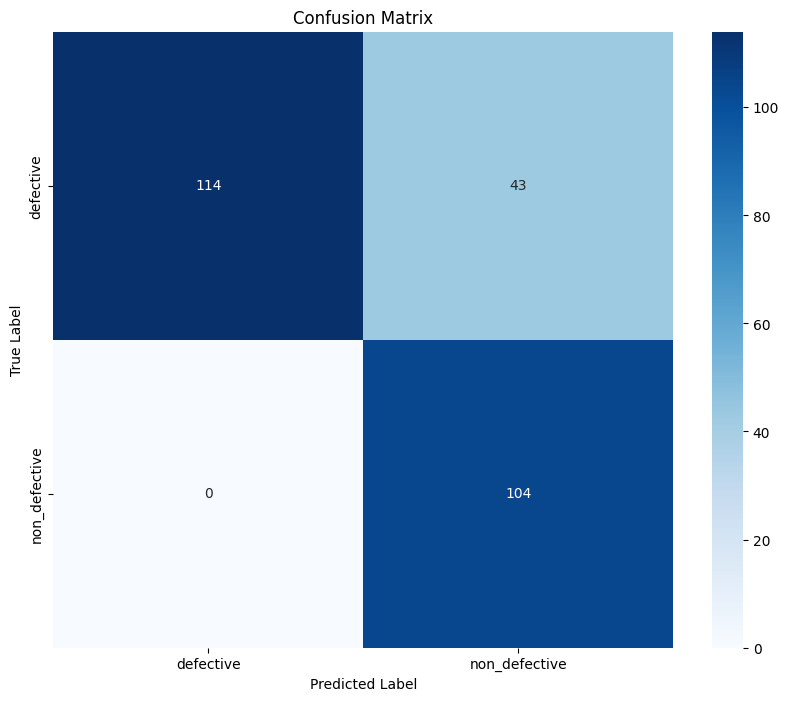

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Test prediction shape: (1, 2)

Verifying model architecture...


Model: "defect_detection_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Testing model prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


Test prediction shape: (1, 2)
Test prediction sample: [0.9540367 0.0459633]

Saving model for TensorFlow.js...


failed to lookup keras version from the file,
    this is likely a weight only file

Verifying saved model files...
Generated files: ['model.json', 'group1-shard1of3.bin', 'group1-shard2of3.bin', 'group1-shard3of3.bin']

Verifying model.json structure...
model.json structure verified successfully

Model saved and verified successfully!


failed to lookup keras version from the file,
    this is likely a weight only file

Model saved successfully!
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 974ms/step - accuracy: 0.7552 - auc: 0.8655 - f1: 0.8198 - loss: 0.6995 - precision: 0.7552 - recall: 0.7552
Metadata file saved at: tfjs_model/model_metadata.json


In [11]:
# CELL 8: Evaluate and Save Model
# Plot training history
def plot_training_history(history1, history2):
    # Combine histories
    total_epochs = len(history1.history['loss']) + len(history2.history['loss'])
    epochs_range = range(1, total_epochs + 1)

    plt.figure(figsize=(15, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(
        history1.history['accuracy'] + history2.history['accuracy'],
        label='Training Accuracy'
    )
    plt.plot(
        history1.history['val_accuracy'] + history2.history['val_accuracy'],
        label='Validation Accuracy'
    )
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(
        history1.history['loss'] + history2.history['loss'],
        label='Training Loss'
    )
    plt.plot(
        history1.history['val_loss'] + history2.history['val_loss'],
        label='Validation Loss'
    )
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Evaluate model
print("Evaluating model on test set...")
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())
print(f"\nClasses: {class_names}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# CELL 8 (model saving part only - replace the corresponding section):

# Save model with explicit input layer configuration
model_version = "1.0.0"

# Create a new model with explicit input layer
input_layer = tf.keras.layers.Input(shape=(224, 224, 3), name='input_1', batch_size=None)

# Important: We need to recreate the MobileNetV2 base model to ensure proper serialization
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Now create the full model architecture
x = base_model(input_layer)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)

# Create the explicit model
explicit_model = tf.keras.Model(inputs=input_layer, outputs=outputs, name='defect_detection_model')

# Compile the explicit model with the same configuration
explicit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.F1Score(name='f1', average='weighted')
    ]
)

# Copy weights from the original model's base
original_base = model.layers[0]
base_model.set_weights(original_base.get_weights())

# Copy weights for the remaining layers
for i in range(1, len(model.layers)):
    layer_weights = model.layers[i].get_weights()
    if len(layer_weights) > 0:
        explicit_model.layers[i+1].set_weights(layer_weights)  # +1 because explicit model has input layer

# Verify the model works with a test input
test_input = tf.zeros((1, 224, 224, 3))
test_output = explicit_model.predict(test_input)
print("Test prediction shape:", test_output.shape)

# Verify model architecture
print("\nVerifying model architecture...")
explicit_model.summary()

# Test prediction on a batch of zeros
print("\nTesting model prediction...")
test_batch = tf.zeros((1, 224, 224, 3))
test_pred = explicit_model.predict(test_batch)
print("Test prediction shape:", test_pred.shape)
print("Test prediction sample:", test_pred[0])

# Save for TensorFlow.js with additional configuration
print("\nSaving model for TensorFlow.js...")
tfjs.converters.save_keras_model(
    explicit_model,
    'tfjs_model'
)

# Verify the saved files
print("\nVerifying saved model files...")
saved_files = os.listdir('tfjs_model')
print("Generated files:", saved_files)

# Verify model.json structure
print("\nVerifying model.json structure...")
with open(os.path.join('tfjs_model', 'model.json'), 'r') as f:
    model_json = json.load(f)
    # Check if modelTopology exists
    if 'modelTopology' not in model_json:
        raise ValueError("model.json is missing modelTopology")
    # Check if weightsManifest exists
    if 'weightsManifest' not in model_json:
        raise ValueError("model.json is missing weightsManifest")
    print("model.json structure verified successfully")

print("\nModel saved and verified successfully!")

# Important: Save the model for TensorFlow.js FIRST, before saving in Keras format
tfjs.converters.save_keras_model(
    explicit_model,
    'tfjs_model'
)

# Then save in Keras format (optional)
explicit_model.save(f'defect_detection_model_v{model_version}.keras', save_format='keras')

print("\nModel saved successfully!")

# Save metadata separately
metadata = {
    "version": model_version,
    "input_shape": [224, 224, 3],
    "classes": class_names,
    "preprocessing": {
        "rescale": 1/255,
        "target_size": [224, 224]
    },
    "model_architecture": "MobileNetV2",
    "training_params": {
        "optimizer": "Adam",
        "loss": "categorical_crossentropy",
        "metrics": ["accuracy", "precision", "recall", "auc", "f1"]
    },
    "performance_metrics": {
        "test_accuracy": float(explicit_model.evaluate(test_generator)[1]),
        "class_mapping": {
            "defective": 0,
            "non_defective": 1
        }
    }
}

# Save metadata to a JSON file
metadata_path = os.path.join('tfjs_model', 'model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata file saved at: {metadata_path}")

# Clean up memory
tf.keras.backend.clear_session()